# Task 11 - Linear Regression Using Gradient Descent

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1- Load and Understand the Data

In [2]:
X = np.array([50, 60, 70, 80, 90], dtype=float)
y = np.array([150, 180, 210, 240, 270], dtype=float)

print("X =", X)
print("y =", y)

X = [50. 60. 70. 80. 90.]
y = [150. 180. 210. 240. 270.]


X represents the house size in square meters.

y represents the house price in thousands.

## 2- Linear Regression Class

In [3]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_history = []

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

    def fit(self, X, y):
        n = len(X)

        for i in range(self.n_iters):
            y_pred = self.predict(X)
            error = y_pred - y

            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

            d_theta_0 = (2 / n) * np.sum(error)
            d_theta_1 = (2 / n) * np.sum(error * X)

            self.theta_0 = self.theta_0 - self.learning_rate * d_theta_0
            self.theta_1 = self.theta_1 - self.learning_rate * d_theta_1

        return self

    def plot_training(self, X, y):
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.semilogy(self.sse_history)
        plt.xlabel("Iteration")
        plt.ylabel("SSE")
        plt.title("SSE over Iterations")

        plt.subplot(1, 2, 2)
        plt.scatter(X, y)
        x_line = np.linspace(X.min(), X.max(), 100)
        y_line = self.predict(x_line)
        plt.plot(x_line, y_line)
        plt.xlabel("House Size")
        plt.ylabel("Price")
        plt.title("Regression Line")

        plt.tight_layout()
        plt.show()

## 3- Create and Train the Model

In [4]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(X, y)

print("theta_0 =", model.theta_0)
print("theta_1 =", model.theta_1)

theta_0 = -1.0055957901462392e+95
theta_1 = -7.326427288635144e+96


### What do theta_0 and theta_1 represent?

- theta_0 is the intercept.
- theta_1 is the slope of the regression line.

The equation is:

y = theta_0 + theta_1 * X

## 4- Prediction

In [5]:
pred_70 = model.predict(np.array([70.0]))[0]
print("Predicted price for 70 m² =", pred_70)

Predicted price for 70 m² = -5.129504697834747e+98


The prediction is not reasonable with learning rate 0.001 because the model diverges.

From the dataset, a 70 m² house should be around 210 thousand.

## 5- Visualization

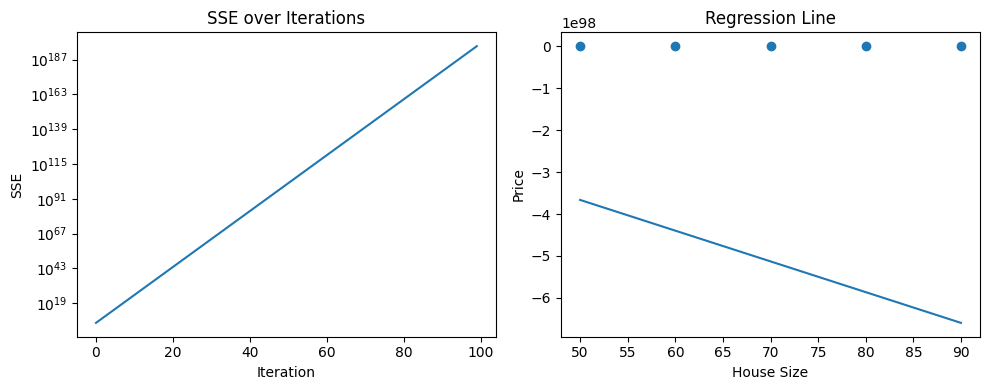

In [6]:
model.plot_training(X, y)

When the learning rate is suitable, SSE decreases because Gradient Descent moves toward the minimum.

Convergence means the model reaches values of theta_0 and theta_1 where the error becomes very small and stops changing much.

Here, learning rate 0.001 is too large for the raw X values, so SSE increases instead of decreasing.

## 6- Experiment with Learning Rates

In [7]:
large_model = LinearRegressionGD(learning_rate=0.002, n_iters=100)
large_model.fit(X, y)

moderate_model = LinearRegressionGD(learning_rate=0.0001, n_iters=100)
moderate_model.fit(X, y)

small_model = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
small_model.fit(X, y)

print("Large learning rate final SSE   =", large_model.sse_history[-1])
print("Moderate learning rate final SSE=", moderate_model.sse_history[-1])
print("Small learning rate final SSE   =", small_model.sse_history[-1])

Large learning rate final SSE   = 2.3044024433564837e+260
Moderate learning rate final SSE= 0.00033181560776546876
Small learning rate final SSE   = 0.00046041150816733306


In [8]:
plt.figure(figsize=(7, 4))

plt.semilogy(large_model.sse_history, label="Large LR = 0.002")
plt.semilogy(moderate_model.sse_history, label="Moderate LR = 0.0001")
plt.semilogy(small_model.sse_history, label="Small LR = 0.00001")

plt.xlabel("Iteration")
plt.ylabel("SSE")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

/opt/pyvenv/lib/python3.13/site-packages/matplotlib/ticker.py:2468: RuntimeWarning: overflow encountered in power
  ticklocs = b ** decades


OverflowError: cannot convert float infinity to integer

<Figure size 700x400 with 1 Axes>

### Comparison

- Large learning rate: the error becomes very large and the model diverges.
- Moderate learning rate: converges fast and gives a very small SSE.
- Small learning rate: converges, but more slowly.

If the learning rate is too large, Gradient Descent can overshoot the minimum and fail to converge.

## 7- Result with a Suitable Learning Rate

theta_0 = 0.04113676040970018
theta_1 = 2.999435373457505
Prediction for 70 m² = 210.00161290243506


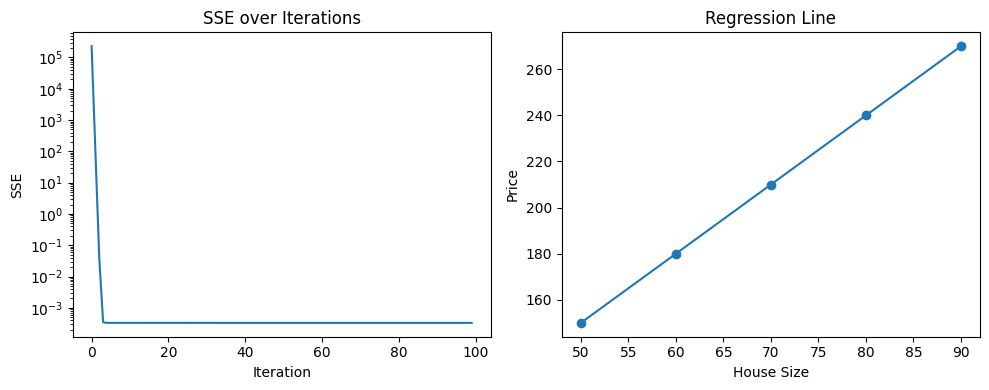

In [9]:
print("theta_0 =", moderate_model.theta_0)
print("theta_1 =", moderate_model.theta_1)

good_prediction = moderate_model.predict(np.array([70.0]))[0]
print("Prediction for 70 m² =", good_prediction)

moderate_model.plot_training(X, y)

The suitable learning rate gives a prediction close to 210 thousand, which matches the dataset.